In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
from xmip.preprocessing import combined_preprocessing
import regionmask
from xmip.regionmask import merged_mask
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import matplotlib.colors as mcolors
import cmocean
import cartopy.crs as ccrs
from scipy.interpolate import PchipInterpolator
# import CM4Xutils #needed to run pip install nc-time-axis
# from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

### Request HPC Resources

In [1]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4X/CM4XTransientTracers/WaterMassBudgets/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=16)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4X/CM4XTransientTracers/WaterMassBudgets/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4X/CM4XTransientTracers/WaterMassBudgets/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/bin/python -m distributed.cli.dask_worker tcp://172.16.3.70:40627 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.70:40627,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [6]:
native_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/transient_tracers_z"
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr",  "CM4Xp125_ssp585_transient_tracers_surface.zarr"]
surface_files = [native_path + "/" + a for a in files]

In [7]:
def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]  - 100
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds

ds = xr.open_mfdataset(full_depth_files, combine="nested", concat_dim="expt", parallel=True, preprocess=preprocess, engine = "zarr")
# ds_surface = xr.open_mfdataset(surface_files, combine="nested", concat_dim="expt", parallel=True, preprocess=preprocess).isel(z_l = 0)

In [8]:
ds = ds.sel(xh = slice(100, 500), yh = slice(200, 430))

In [9]:
p_ref = xr.apply_ufunc(
    gsw.p_from_z, -ds.z_l, ds.geolat, 0, 0, dask="parallelized"
)

ds["sa"] = xr.apply_ufunc(
    gsw.SA_from_SP,
    ds["so"],
    p_ref,
    ds["geolon"],
    ds["geolat"],
    dask="parallelized",
)

ds["ct"] = xr.apply_ufunc(
gsw.CT_from_pt,
ds["sa"],
ds["thetao"],
dask="parallelized")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 20.04 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


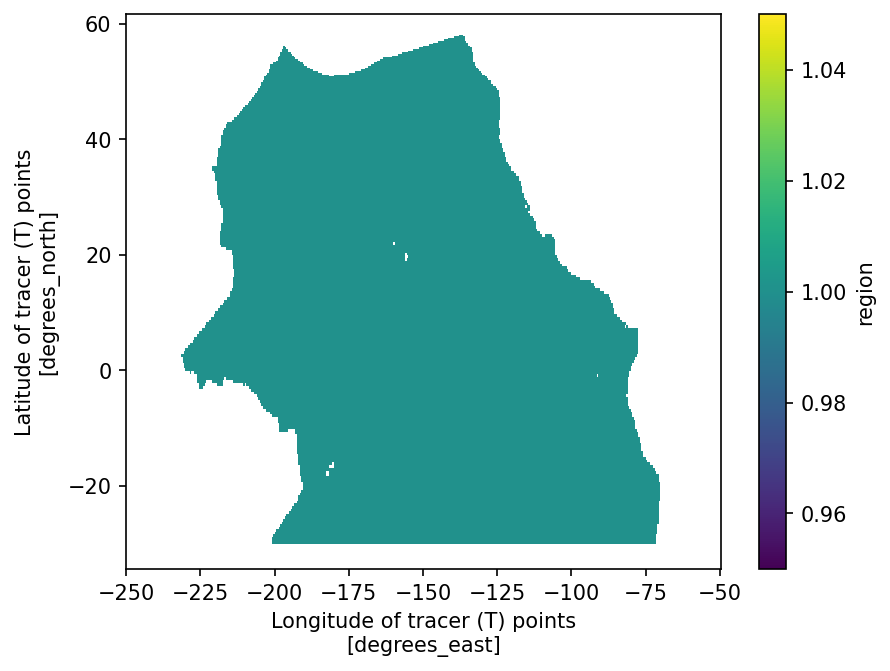

In [10]:
basins = regionmask.defined_regions.natural_earth_v5_1_2.ocean_basins_50
# basins.plot(add_ocean=False, add_label=False)
basin_masks = basins.mask(ds.geolon, ds.geolat)
PAC_mask =  1. * (basin_masks.where((basin_masks == 3) + (basin_masks == 4)) > 0.0)
PAC_mask = PAC_mask.where((PAC_mask > 0) * (ds.wet > 0) * (ds.geolat > -30))
PAC_mask.plot(x = "geolon", y = "geolat")

In [14]:
def volume_weighted_average(ds):
    weights = ds.volcello
    weights = weights.where(weights > 0)
    weighted_ds = (ds[["sa", "ct", "cfc11", "sf6"]] * weights).sum(["xh", "yh"], skipna = True) / weights.sum(["xh", "yh"], skipna = True)
    return weighted_ds

In [15]:
ds["PAC_mask"] = PAC_mask

In [16]:
hov = volume_weighted_average(ds.where(ds["PAC_mask"] > 0)).compute()

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 10.29 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [17]:
import cmocean.cm as cmo
import seaborn as sns
sns.set_context('notebook')
hov["rho2"] = gsw.sigma2(hov["sa"],hov["ct"])

In [18]:
hov_ctrl = hov.sel(expt = "control").sel(year = slice(2015, None))
hov_forced = hov.sel(expt = "forced").sel(year = slice(2015, None))

Text(0, 0.5, 'depth [m]')

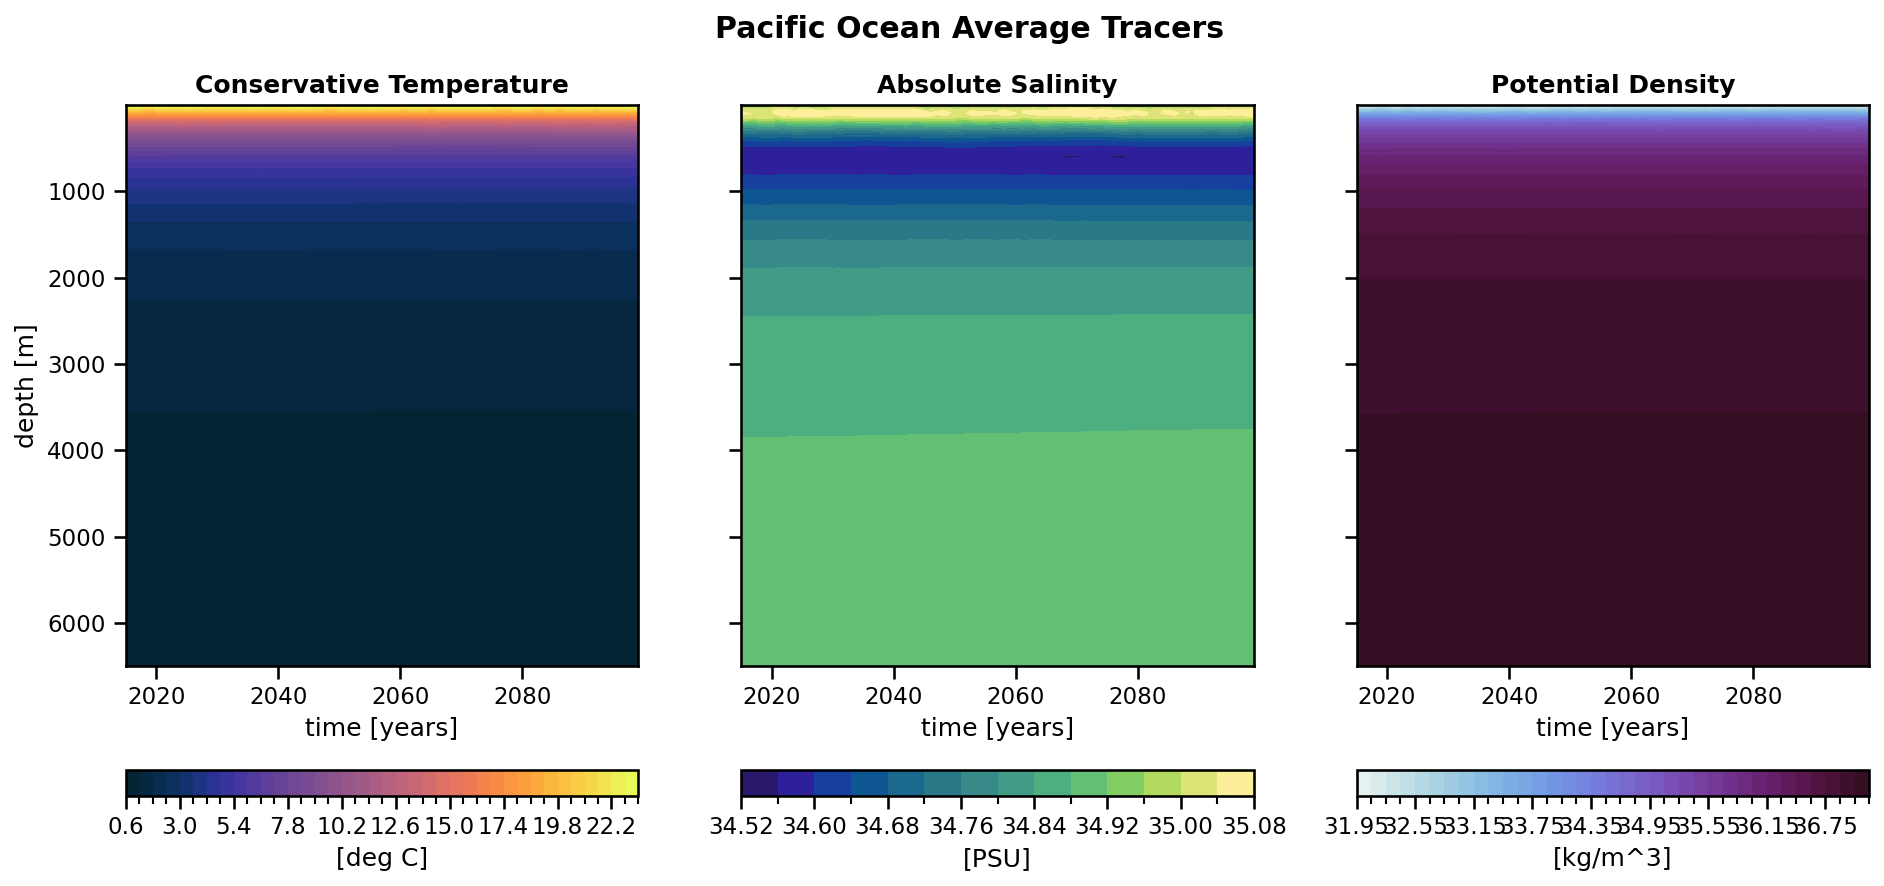

In [19]:
fig, ax = plt.subplots(1, 3, figsize = (15, 6), sharey = True)
fig.suptitle("Pacific Ocean Average Tracers", fontweight = "bold")

hov_ctrl.ct.T.plot.contourf(ax = ax[0], yincrease = False, levels = 45, cmap = cmo.thermal, 
                       cbar_kwargs = {"location": "bottom", "fraction" : 0.04, "label":"[deg C]"})
ax[0].set_title("Conservative Temperature", fontweight = "bold")

hov_ctrl.sa.T.plot.contourf(ax = ax[1], yincrease = False, levels = 15, cmap = cmo.haline, 
                       cbar_kwargs = {"location": "bottom", "fraction" : 0.04, "label":"[PSU]"})
ax[1].set_title("Absolute Salinity", fontweight = "bold")

hov_ctrl.rho2.T.plot.contourf(ax = ax[2], yincrease = False, levels = 45, cmap = cmo.dense, 
                       cbar_kwargs = {"location": "bottom", "fraction" : 0.04, "label":"[kg/m^3]"})
ax[2].set_title("Potential Density", fontweight = "bold")

[a.set_ylabel("") for a in ax]
[a.set_xlabel("time [years]") for a in ax]
ax[0].set_ylabel("depth [m]")


Text(0, 0.5, 'depth [m]')

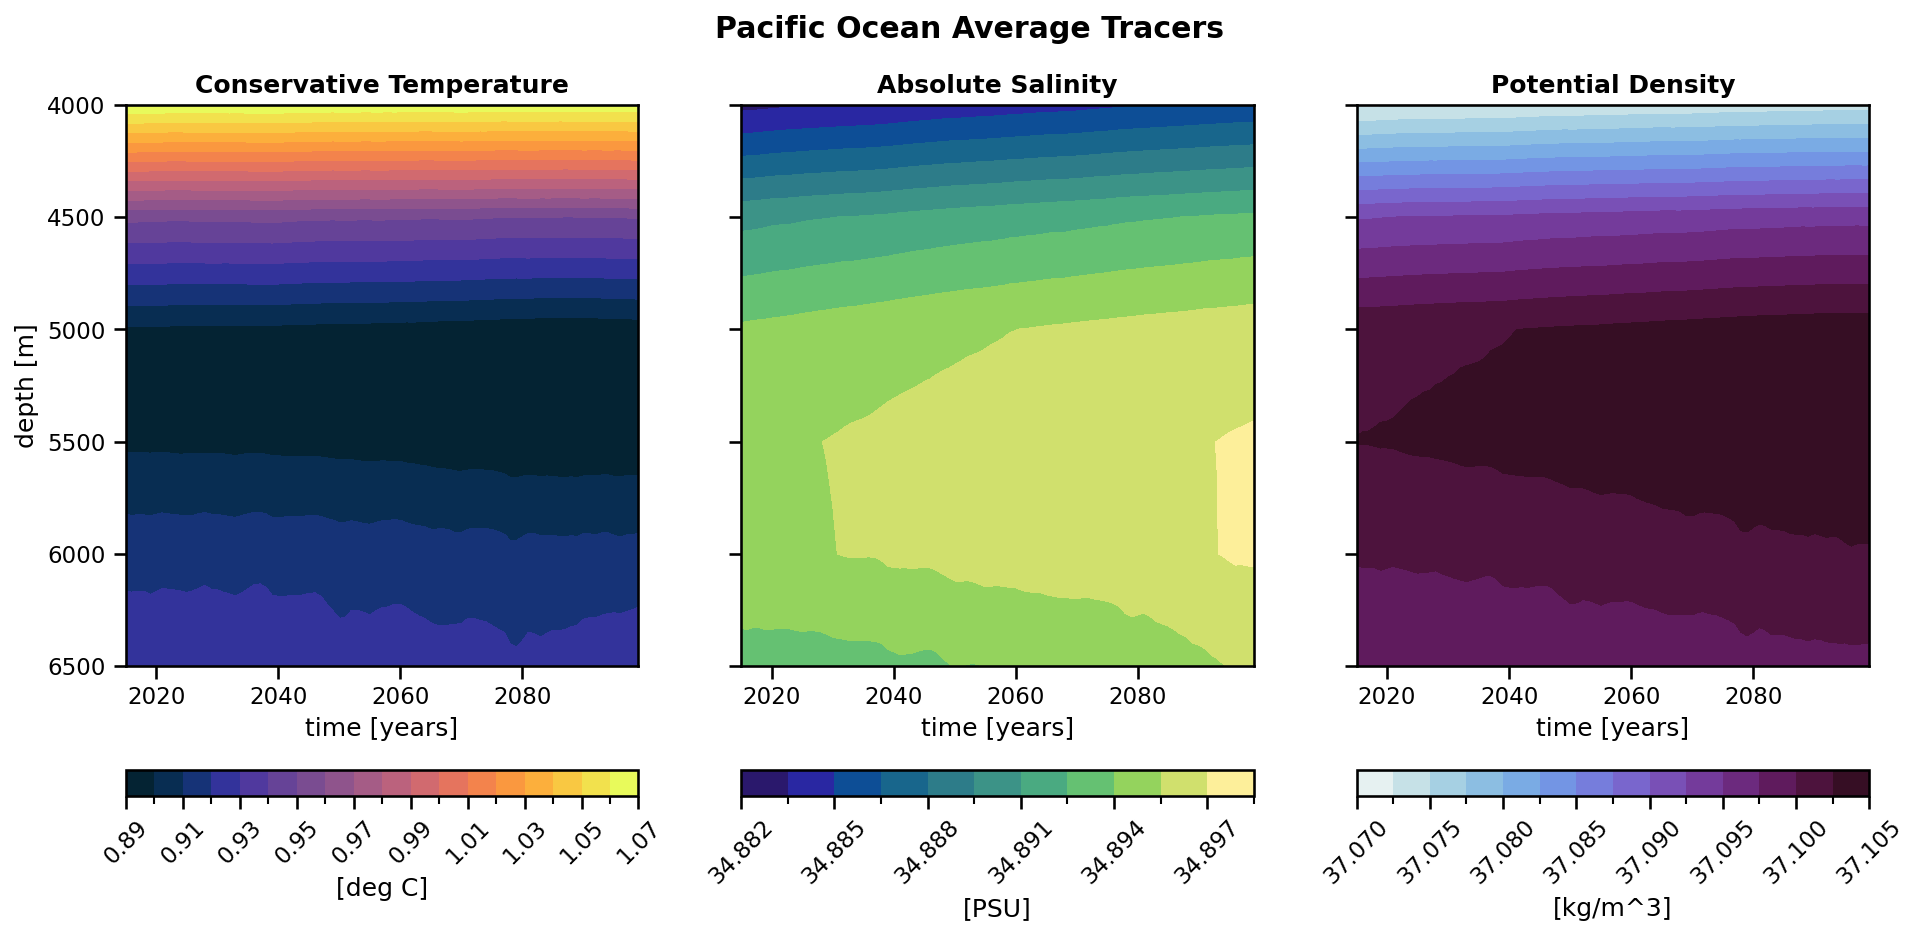

In [20]:
hov_cropped = hov_ctrl.sel(z_l = slice(4000, None))

fig, ax = plt.subplots(1, 3, figsize = (15, 6), sharey = True)
fig.suptitle("Pacific Ocean Average Tracers", fontweight = "bold")

p = hov_cropped.ct.T.plot.contourf(ax = ax[0], yincrease = False, levels = 20, cmap = cmo.thermal, 
                       cbar_kwargs = {"location": "bottom", "fraction" : 0.04, "label":"[deg C]"})
ax[0].set_title("Conservative Temperature", fontweight = "bold")
p.colorbar.ax.tick_params(axis='x', rotation=45)

p = hov_cropped.sa.T.plot.contourf(ax = ax[1], yincrease = False, levels = 12, cmap = cmo.haline, 
                       cbar_kwargs = {"location": "bottom", "fraction" : 0.04, "label":"[PSU]"})
ax[1].set_title("Absolute Salinity", fontweight = "bold")
p.colorbar.ax.tick_params(axis='x', rotation=45)

p = hov_cropped.rho2.T.plot.contourf(ax = ax[2], yincrease = False, levels = 15, cmap = cmo.dense, 
                       cbar_kwargs = {"location": "bottom", "fraction" : 0.04, "label":"[kg/m^3]"})
ax[2].set_title("Potential Density", fontweight = "bold")
p.colorbar.ax.tick_params(axis='x', rotation=45)

[a.set_ylabel("") for a in ax]
[a.set_xlabel("time [years]") for a in ax]
ax[0].set_ylabel("depth [m]")


Text(0, 0.5, 'depth [m]')

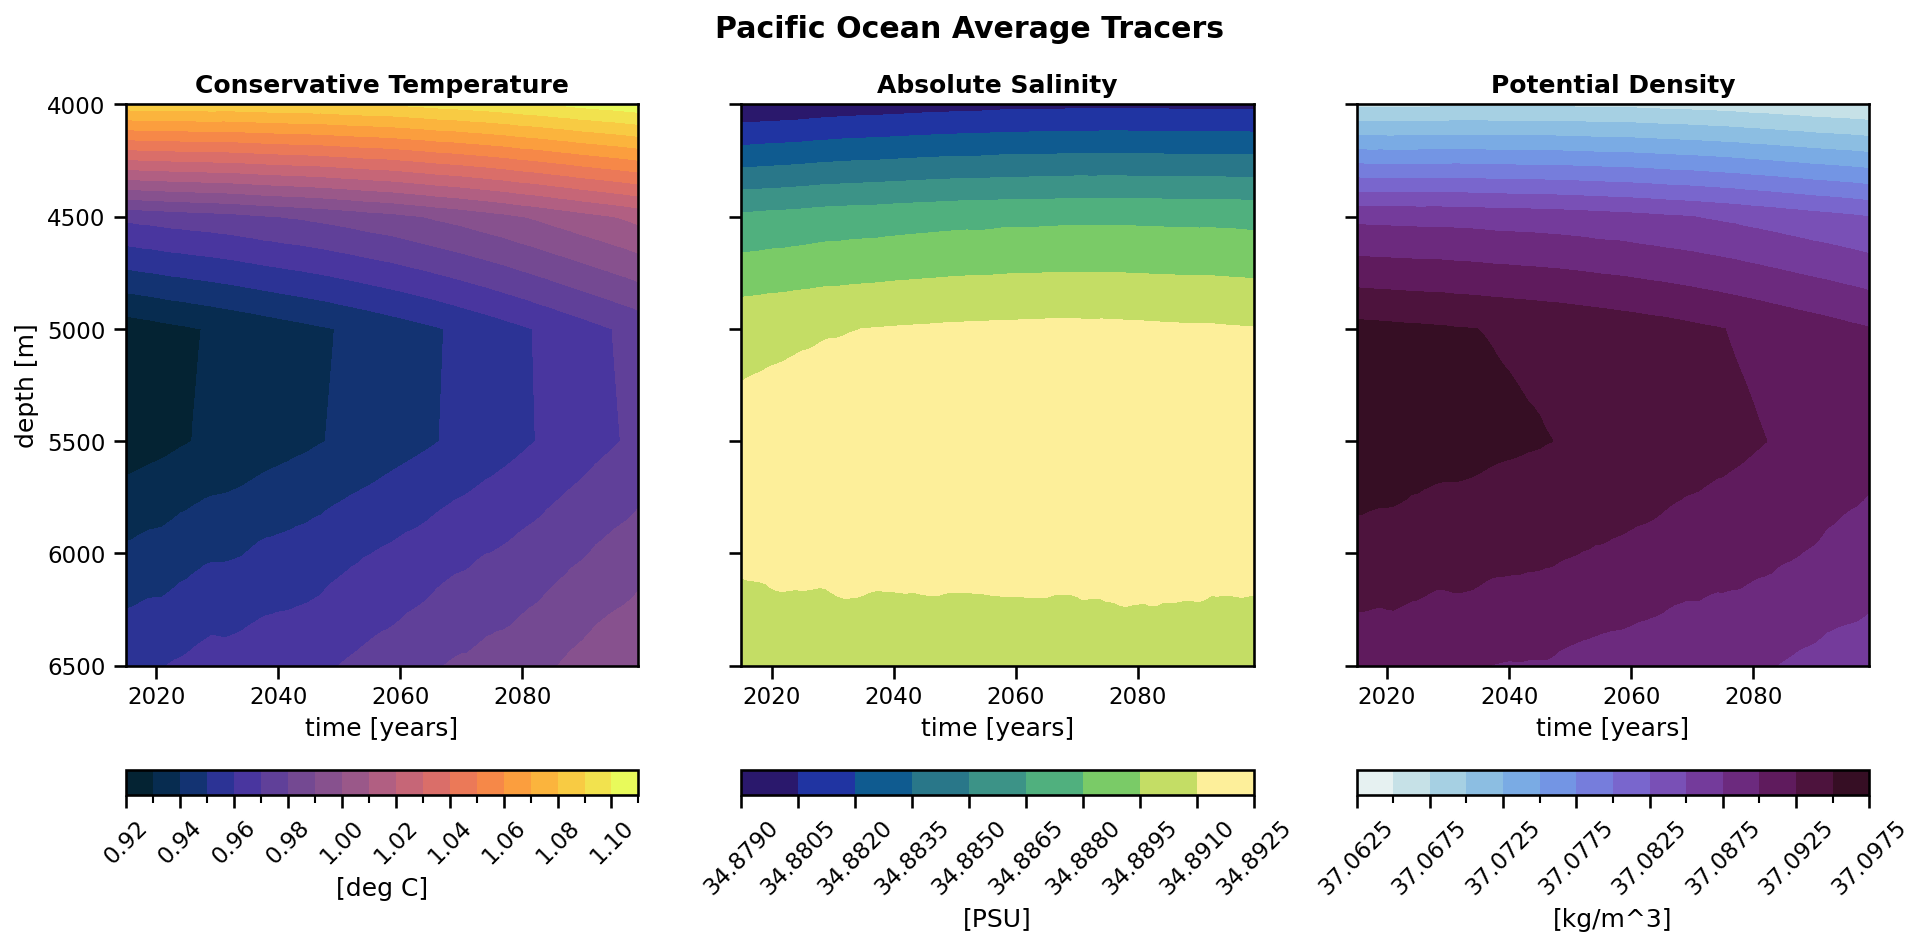

In [21]:
hov_cropped = hov_forced.sel(z_l = slice(4000, None))

fig, ax = plt.subplots(1, 3, figsize = (15, 6), sharey = True)
fig.suptitle("Pacific Ocean Average Tracers", fontweight = "bold")

p = hov_cropped.ct.T.plot.contourf(ax = ax[0], yincrease = False, levels = 20, cmap = cmo.thermal, 
                       cbar_kwargs = {"location": "bottom", "fraction" : 0.04, "label":"[deg C]"})
ax[0].set_title("Conservative Temperature", fontweight = "bold")
p.colorbar.ax.tick_params(axis='x', rotation=45)

p = hov_cropped.sa.T.plot.contourf(ax = ax[1], yincrease = False, levels = 12, cmap = cmo.haline, 
                       cbar_kwargs = {"location": "bottom", "fraction" : 0.04, "label":"[PSU]"})
ax[1].set_title("Absolute Salinity", fontweight = "bold")
p.colorbar.ax.tick_params(axis='x', rotation=45)

p = hov_cropped.rho2.T.plot.contourf(ax = ax[2], yincrease = False, levels = 15, cmap = cmo.dense, 
                       cbar_kwargs = {"location": "bottom", "fraction" : 0.04, "label":"[kg/m^3]"})
ax[2].set_title("Potential Density", fontweight = "bold")
p.colorbar.ax.tick_params(axis='x', rotation=45)

[a.set_ylabel("") for a in ax]
[a.set_xlabel("time [years]") for a in ax]
ax[0].set_ylabel("depth [m]")

In [22]:
def calculate_spice_1d(var_profile, rho_profile, rho_ref, z_levels, ref_idx):
    """
    Decomposes property anomalies into heave and spice components for a single column.

    This function maps a vertical property profile from depth space to density space,
    calculates changes on isopycnal surfaces (spice), and maps them back to the
    reference depth grid.

    Parameters
    ----------
    var_profile : ndarray
        The property to decompose (e.g., Temperature), shape (nt, nz).
    rho_profile : ndarray
        Potential density profiles, shape (nt, nz).
    rho_ref : ndarray
        Target density surfaces for the isopycnal mapping, shape (n_rho,).
    z_levels : ndarray
        Vertical depth coordinates (must be monotonic), shape (nz,).
    ref_idx : int
        The index along the time dimension (nt) to use as the reference state.

    Returns
    -------
    spice_anom : ndarray
        The spice component of the property anomaly, shape (nt, nz).
        Returns NaNs if the column is unstable or contains insufficient data.
    """
    nt, nz = var_profile.shape
    n_rho = len(rho_ref)
    
    # Pre-allocate output array
    spice_on_z = np.full((nt, nz), np.nan)
    
    # --- Physical Validation ---
    # 1. Check for density inversions (diff <= 0 indicates instability)
    # 2. Ensure the column is not entirely land/missing data
    if np.any(np.diff(rho_profile, axis=1) <= 0) or np.isnan(var_profile).all():
        return spice_on_z

    # Temporary storage for isopycnal-space variables
    var_on_rho = np.full((nt, n_rho), np.nan)
    z_on_rho   = np.full((nt, n_rho), np.nan)

    # --- Step 1: Depth Space to Density Space (Isopycnal Projection) ---
    for t in range(nt):
        v_t, r_t = var_profile[t], rho_profile[t]
        mask = ~np.isnan(v_t) & ~np.isnan(r_t)
        
        if mask.sum() > 3:
            # Interpolate property and depth onto target density surfaces
            var_on_rho[t] = PchipInterpolator(r_t[mask], v_t[mask], extrapolate=False)(rho_ref)
            z_on_rho[t]   = PchipInterpolator(r_t[mask], z_levels[mask], extrapolate=False)(rho_ref)

    # --- Step 2: Density Space to Depth Space (Reference Mapping) ---
    # Map back to z using the depth-density relationship from the reference year
    z_ref_at_rho = z_on_rho[ref_idx]
    z_mask = ~np.isnan(z_ref_at_rho)
    
    if z_mask.any():
        for t in range(nt):
            v_sig = var_on_rho[t]
            # Must have valid data and a valid depth mapping for this density level
            valid_mask = ~np.isnan(v_sig) & z_mask
            
            if valid_mask.sum() > 3:
                cs = PchipInterpolator(z_ref_at_rho[valid_mask], v_sig[valid_mask], extrapolate=False)
                spice_on_z[t, :] = cs(z_levels)

    # Spice anomaly is defined as the change in the property on density surfaces
    # relative to the reference year's configuration.

    spice_on_z_anom = spice_on_z - spice_on_z[ref_idx, :]
    # spice_on_z_anom[np.isnan(spice_on_z_anom)] = 0.0
    return spice_on_z_anom

def apply_heave_spice_decomposition(ds, rho_ref, ref_year, var_name="ct", 
                                   time_dim="year", depth_dim="z_l"):
    """
    Parallelized 4D orchestrator using xr.apply_ufunc.
    Automatically vectorizes over any spatial dimensions (e.g., xh, yh).
    """
    # Chunk Validation
    if hasattr(ds[var_name], "chunks") and ds[var_name].chunks is not None:
        for dim in [time_dim, depth_dim]:
            if len(ds.chunks.get(dim, (1,))) > 1:
                raise ValueError(f"'{dim}' must be contiguous. Run: ds = ds.chunk({{{dim}: -1}})")

    # Identify reference index
    time_coords = ds[time_dim].values.tolist()
    ref_idx = time_coords.index(ref_year)
    
    # Calculate Spice
    spice_anom = xr.apply_ufunc(
        calculate_spice_1d,
        ds[var_name], ds.rho2, rho_ref, ds[depth_dim], ref_idx,
        input_core_dims=[[time_dim, depth_dim], [time_dim, depth_dim], ["rho_ref"], [depth_dim], []],
        output_core_dims=[[time_dim, depth_dim]],
        vectorize=True,      
        dask="parallelized", 
        output_dtypes=[ds[var_name].dtype]
    )

    # Assemble Result Dataset
    ds_out = ds[[var_name]].copy()
    ds_out[var_name] = ds[var_name] - ds[var_name].sel({time_dim: ref_year})
    ds_out[f"{var_name}_spice"] = spice_anom
    ds_out[f"{var_name}_heave"] = ds_out[var_name] - ds_out[f"{var_name}_spice"]
    ds_out[f"{var_name}_residual"] = ds_out[var_name] - (
        ds_out[f"{var_name}_spice"].fillna(0) + ds_out[f"{var_name}_heave"].fillna(0)
    )
    
    return ds_out

In [100]:
new_z = np.arange(1000, 5500 + 0.1, 50)
rho_standard = np.arange(30., 42., 0.00001)
ref_year = 2015
hov_cropped = hov.interp(z_l = new_z)
hov_cropped = hov_cropped.sel(z_l = slice(1000, 5450)).sel(year = slice("2015", None))
heave_spice_all = apply_heave_spice_decomposition(hov_cropped, rho_standard, ref_year, var_name="ct")

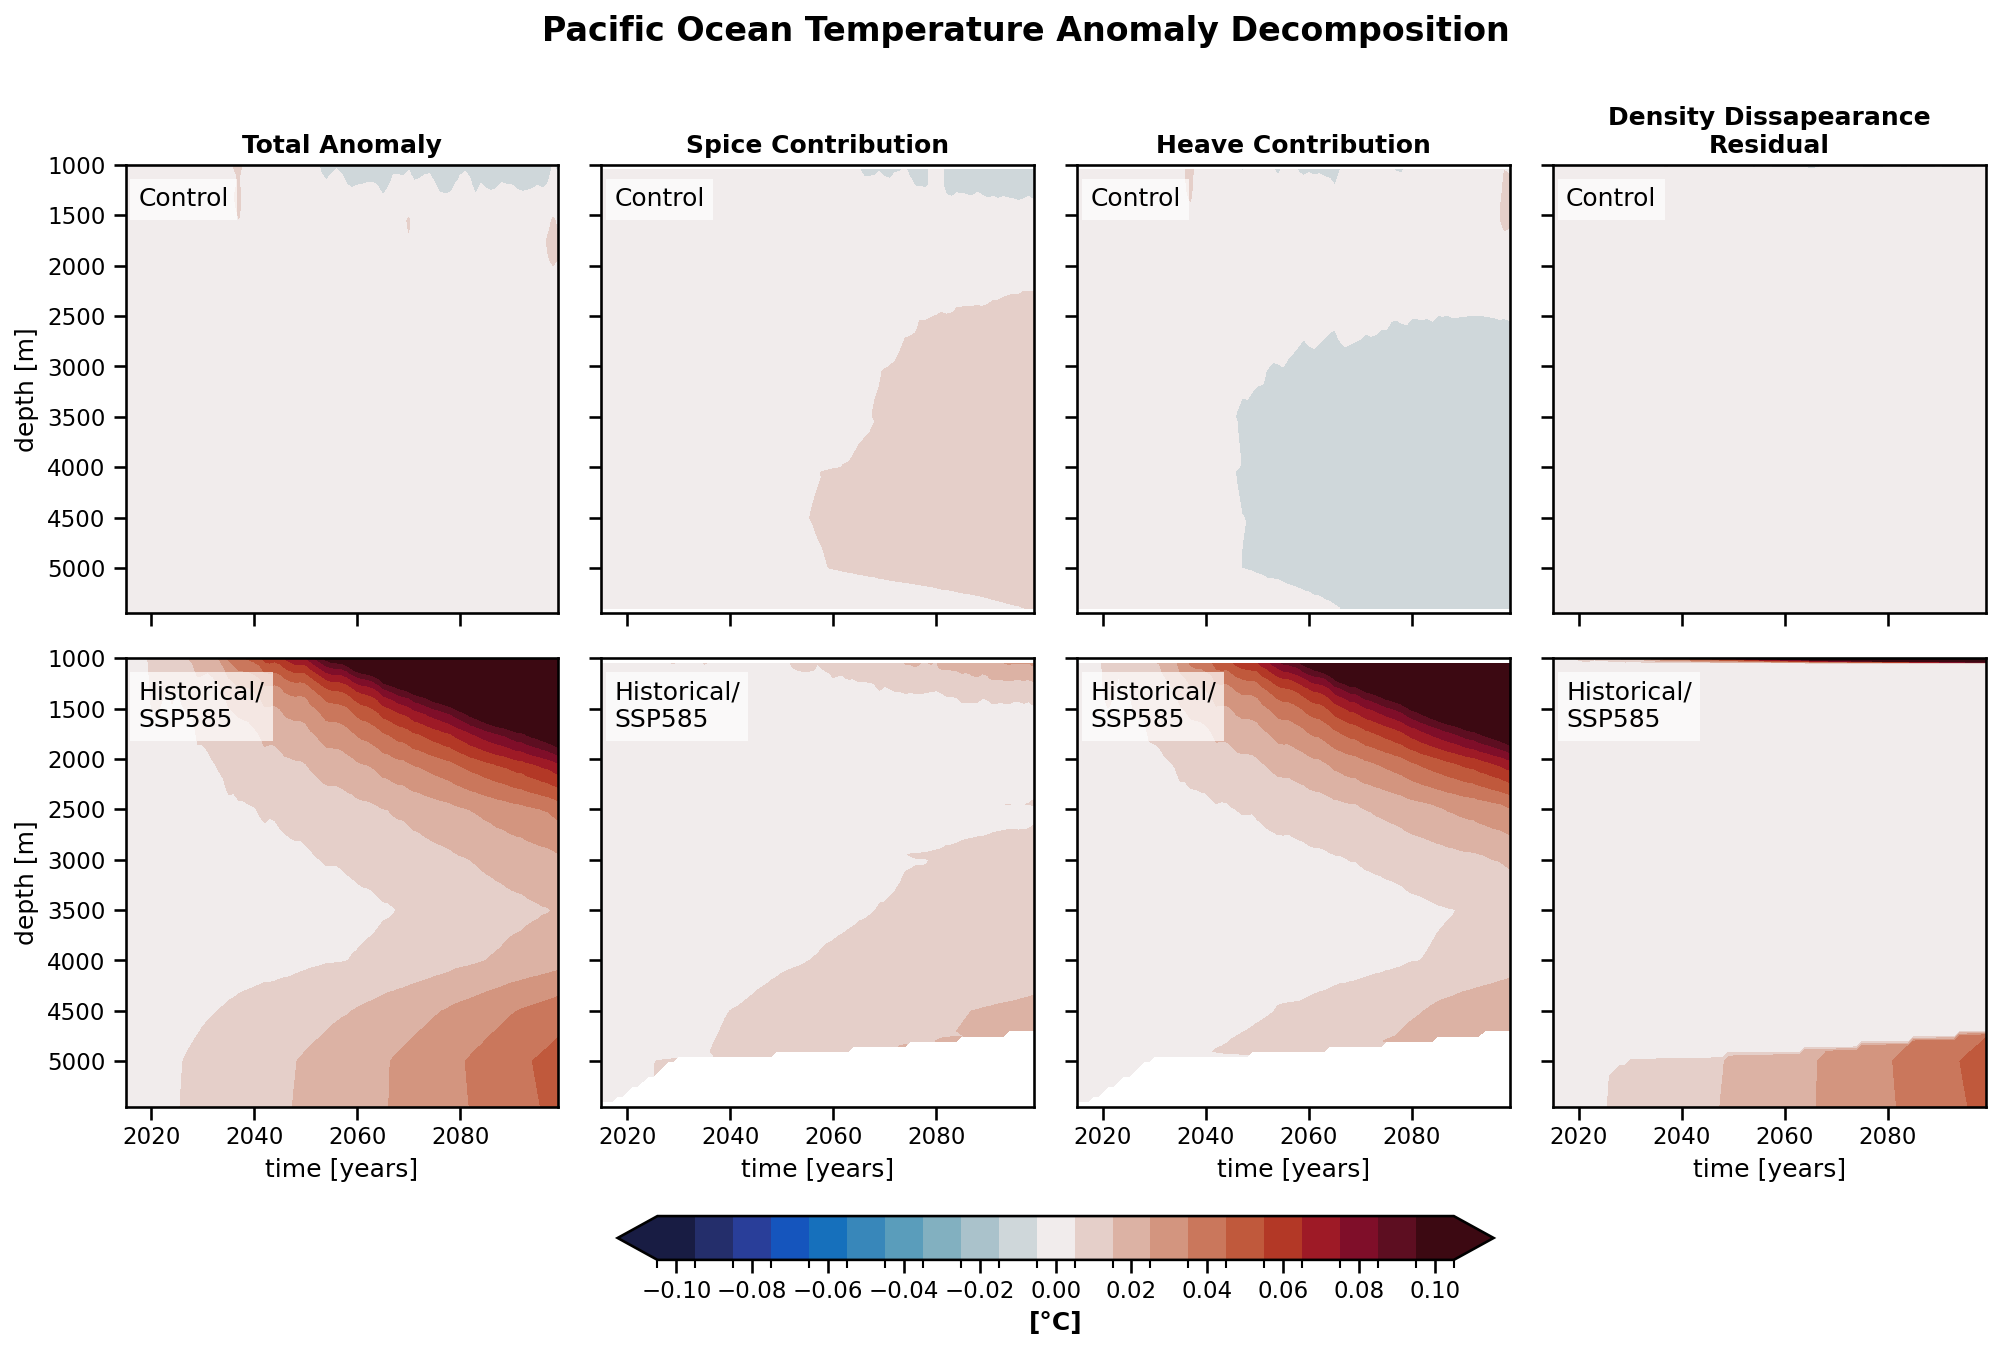

In [101]:
fig, ax = plt.subplots(2, 4, figsize=(16, 10), sharey=True, sharex=True)
fig.suptitle("Pacific Ocean Temperature Anomaly Decomposition", fontweight="bold", fontsize=16)

levels = np.arange(-10.5, 11.5, 1.0) / 100
clevels = np.arange(-10, 11, 2) / 100
num_bins = len(levels) - 1 
cmap = cmocean.cm.balance.resampled(num_bins)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=num_bins)

expts = ["control", "forced"]
expt_names = ["Control", "Historical/\nSSP585"]

titles = ["Total Anomaly", "Spice Contribution", "Heave Contribution", "Density Dissapearance\nResidual"]
vars_list = ["ct", "ct_spice", "ct_heave", "ct_residual"]

for row, expt in enumerate(expts):
    ds_expt = heave_spice_all.sel(expt=expt)
    
    for col, vname in enumerate(vars_list):
        current_ax = ax[row, col]
        
        p = ds_expt[vname].T.plot.contourf(ax=current_ax, yincrease=False, levels=levels, 
                                           cmap=cmap, norm=norm, add_colorbar=False, extend="both")
        
        current_ax.text(0.03, 0.95, expt_names[row], transform=current_ax.transAxes, 
                        fontsize=12, va='top', ha='left',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        # Standard labeling logic
        if row == 0: current_ax.set_title(titles[col], fontweight="bold")
        else: current_ax.set_title("")
            
        if row == 1: current_ax.set_xlabel("time [years]")
        else: current_ax.set_xlabel("")
            
        ax[row, col].set_ylabel("")
    ax[row, 0].set_ylabel("depth [m]")

fig.subplots_adjust(hspace=0.1, wspace=0.1, bottom=0.15)
cbar = fig.colorbar(p, ax=ax, orientation="horizontal", extend="both", fraction = 0.04, pad = 0.1)
cbar.set_ticks(clevels) 
cbar.set_label("[°C]", fontweight="bold")

In [95]:
new_z = np.arange(1000, 5500 + 0.1, 50)
rho_standard = np.arange(30., 42., 0.00001)
ref_year = 2015
hov_cropped = hov.interp(z_l = new_z)
hov_cropped = hov_cropped.sel(z_l = slice(1000, 5450)).sel(year = slice("2015", None))
heave_spice_all = (1e12/1035) * apply_heave_spice_decomposition(hov_cropped, rho_standard, ref_year, var_name="cfc11")

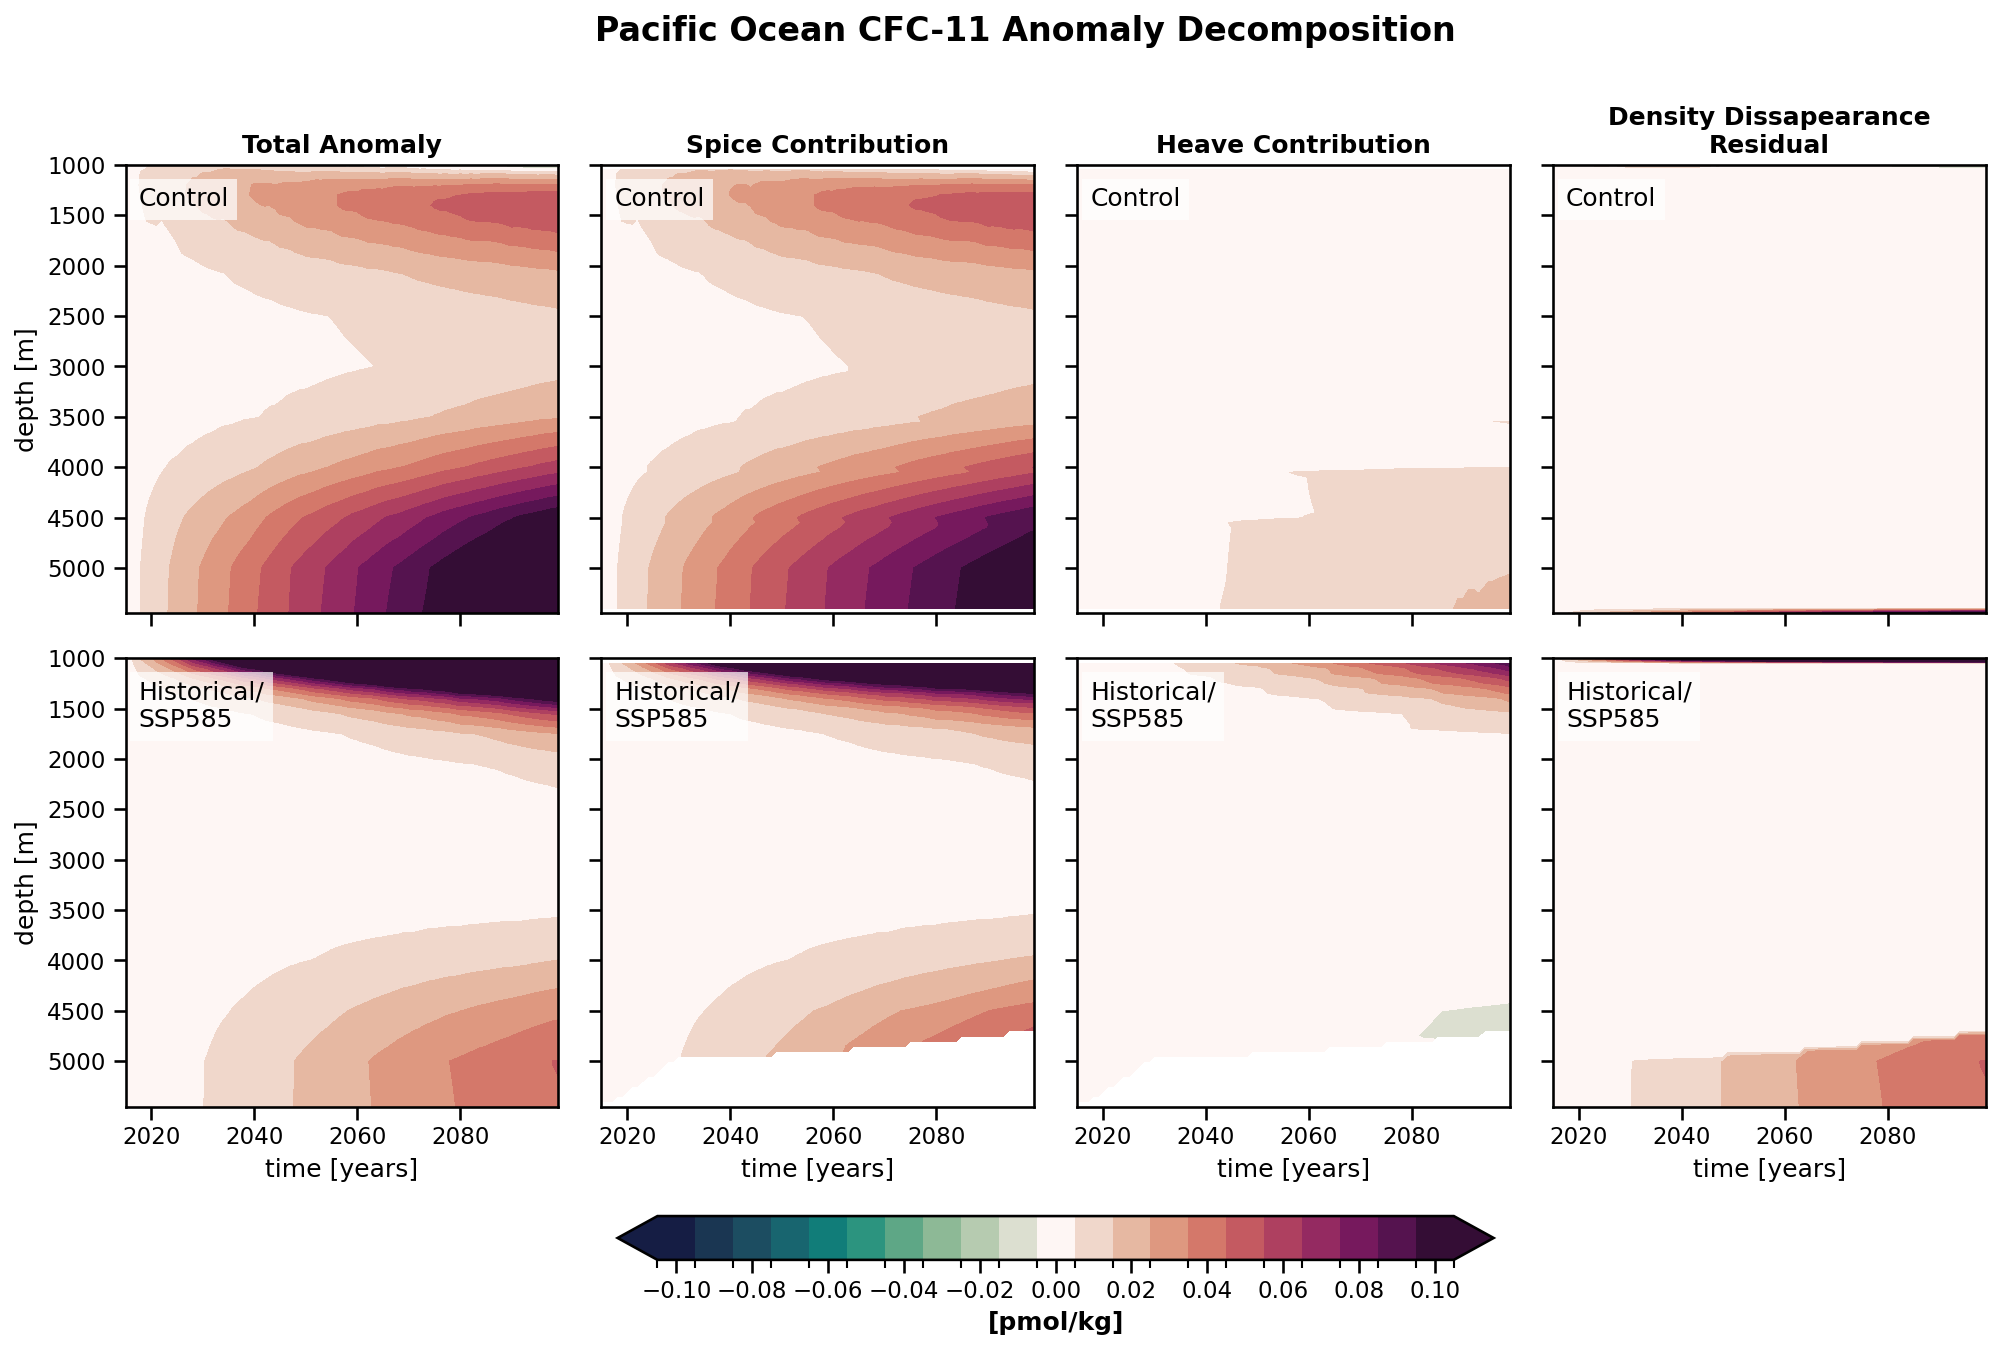

In [98]:
fig, ax = plt.subplots(2, 4, figsize=(16, 10), sharey=True, sharex=True)
fig.suptitle("Pacific Ocean CFC-11 Anomaly Decomposition", fontweight="bold", fontsize=16)

levels = np.arange(-10.5, 11.5, 1.0) / 100
clevels = np.arange(-10, 11, 2) / 100
num_bins = len(levels) - 1 
cmap = cmocean.cm.curl.resampled(num_bins)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=num_bins)

expts = ["control", "forced"]
expt_names = ["Control", "Historical/\nSSP585"]

titles = ["Total Anomaly", "Spice Contribution", "Heave Contribution", "Density Dissapearance\nResidual"]
vars_list = ["cfc11", "cfc11_spice", "cfc11_heave", "cfc11_residual"]

for row, expt in enumerate(expts):
    ds_expt = heave_spice_all.sel(expt=expt)
    
    for col, vname in enumerate(vars_list):
        current_ax = ax[row, col]
        
        p = ds_expt[vname].T.plot.contourf(ax=current_ax, yincrease=False, levels=levels, 
                                           cmap=cmap, norm=norm, add_colorbar=False, extend="both")
        
        current_ax.text(0.03, 0.95, expt_names[row], transform=current_ax.transAxes, 
                         fontsize=12, va='top', ha='left',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        # Standard labeling logic
        if row == 0: current_ax.set_title(titles[col], fontweight="bold")
        else: current_ax.set_title("")
            
        if row == 1: current_ax.set_xlabel("time [years]")
        else: current_ax.set_xlabel("")
            
        ax[row, col].set_ylabel("")
    ax[row, 0].set_ylabel("depth [m]")

fig.subplots_adjust(hspace=0.1, wspace=0.1, bottom=0.15)
cbar = fig.colorbar(p, ax=ax, orientation="horizontal", extend="both", fraction = 0.04, pad = 0.1)
cbar.set_ticks(clevels) 
cbar.set_label("[pmol/kg]", fontweight="bold")

In [36]:
def area_weighted_average(ds, weights = None):
    if weights is None:
        weights = ds.areacello
        weights = weights.where(ds.volcello > 0)
    var_list = [v for v in ds.data_vars.keys() if v not in ["volcello", "thkcello"]]
    weighted_ds = (ds[var_list] * weights).sum(["xh", "yh"], skipna = True) / weights.sum(["xh", "yh"], skipna = True)
    return weighted_ds

In [53]:
ds_chunked = ds[["sa", "ct", "volcello", "PAC_mask"]].chunk({"z_l":-1, "year":-1, "xh":25, "yh":25, "expt":1})
ds_chunked["rho2"] = gsw.sigma2(ds_chunked["sa"],ds_chunked["ct"])

In [54]:
rho_standard = np.arange(35., 50., 0.00001)
ref_year = 2015
ds_heave_spice_all = 100 * apply_heave_spice_decomposition(ds_chunked, rho_standard, ref_year, var_name="ct")

In [55]:
ds_heave_spice_all["volcello"] = ds_chunked["volcello"].sel(xh = ds_heave_spice_all.xh, yh = ds_heave_spice_all.yh)
ds_heave_spice_all["PAC_mask"] = ds_chunked["PAC_mask"].sel(xh = ds_heave_spice_all.xh, yh = ds_heave_spice_all.yh)

In [56]:
weights = ds_heave_spice_all.areacello
weights = weights.where(ds_heave_spice_all.volcello > 0)

ds_heave_spice_area_avg = area_weighted_average(ds_heave_spice_all, weights = weights)

In [57]:
vol_avg_heave_spice = ds_heave_spice_area_avg.compute()

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 24.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
Task exception was never retrieved
future: <Task finished name='Task-221397' coro=<Client._gather.<locals>.wait() done, defined at /vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/client.py:2388> exception=AllExit()>
Traceback (most recent call last):
  File "/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/client.py", line 2397, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished 

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(16, 10), sharey=True, sharex=True)
fig.suptitle("Pacific Ocean Temperature Anomaly Decomposition", fontweight="bold", fontsize=16)

levels = np.arange(-10.5, 11.5, 1.0) 
num_bins = len(levels) - 1 
cmap = cmocean.cm.balance.resampled(num_bins)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=num_bins)

expts = ["control", "forced"]
expt_names = ["Control", 
titles = ["Total Anomaly", "Spice Contribution", "Heave Contribution", "Transformation Residual"]
vars_list = ["ct", "ct_spice", "ct_heave", "ct_residual"]

for row, expt in enumerate(expts):
    ds_expt = vol_avg_heave_spice.sel(expt=expt)
    
    for col, vname in enumerate(vars_list):
        current_ax = ax[row, col]
        
        p = ds_expt[vname].T.plot.contourf(ax=current_ax, yincrease=False, levels=levels, 
                                           cmap=cmap, norm=norm, add_colorbar=False, extend="both")
        
        current_ax.text(0.02, 0.95, expt.upper(), transform=current_ax.transAxes, 
                        fontweight='bold', fontsize=12, va='top', ha='left',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        # Standard labeling logic
        if row == 0: current_ax.set_title(titles[col], fontweight="bold")
        else: current_ax.set_title("")
            
        if row == 1: current_ax.set_xlabel("time [years]")
        else: current_ax.set_xlabel("")
            
        ax[row, col].set_ylabel("")
    ax[row, 0].set_ylabel("depth [m]")

fig.subplots_adjust(hspace=0.1, wspace=0.1, bottom=0.15)
cbar = fig.colorbar(p, ax=ax, orientation="horizontal", extend="both", fraction = 0.04, pad = 0.1)
cbar.set_ticks(np.arange(-10, 11, 2)) 
cbar.set_label("Temperature Anomaly [°C]", fontweight="bold")